# Hypothesis Testing — Patient Return Patterns
**ASA DataFest 2026 — Stormont Vail Health**

---

Six chi-square tests of independence on the binary outcome **Single Visit vs. Multiple Visits**.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'figure.facecolor': 'white'})
BLUE = '#378ADD'
GREEN = '#22C55E'
RED   = '#EF4444'
print('Setup complete')


Setup complete


## 1. Load & Prepare Data

In [2]:
diag  = pd.read_csv('../data/diagnosis.csv')
enct  = pd.read_csv('../data/encounters.csv')
pat   = pd.read_csv('../data/patients.csv')

def assign_age_group(year):
    if year >= 2024: return 'Early Stage'
    if year >= 2014: return 'Children'
    if year >= 2006: return 'Adolescence'
    if year >= 1987: return 'Early Adulthood (21-39)'
    if year >= 1960: return '40-64'
    return '65+'

pat['age_group']   = pat['PatientBirthYearBin'].apply(assign_age_group)
pat['county_fips'] = pat['CensusBlockGroupFipsCode'].astype(str).str[:6]

enct['admit_dt'] = pd.to_datetime(
    enct[['AdmitYear','AdmitMonth','AdmitDay','AdmitHour','AdmitMinute']]
    .rename(columns={'AdmitYear':'year','AdmitMonth':'month','AdmitDay':'day',
                     'AdmitHour':'hour','AdmitMinute':'minute'}),
    errors='coerce'
)

diag_unique = diag[['DiagnosisKey','GroupCode']].drop_duplicates()
diag_unique['first_char'] = (
    diag_unique['GroupCode'].str.replace(r'^ICD-10-CM: ', '', regex=True).str[0]
)

visit_counts = (enct.groupby('PatientDurableKey')
                .size().reset_index(name='total_encounters'))
visit_counts['visit_group'] = visit_counts['total_encounters'].apply(
    lambda n: 'Single Visit' if n == 1 else 'Multiple Visits'
)

first_enc = (enct.sort_values(['PatientDurableKey','admit_dt'])
             .groupby('PatientDurableKey', as_index=False).first())

conversion = (
    first_enc
    .merge(visit_counts,  on='PatientDurableKey', how='left')
    .merge(pat,           left_on='PatientDurableKey', right_on='DurableKey', how='left')
    .merge(diag_unique,   left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='left')
    .dropna(subset=['age_group','first_char','AdmissionType','VisitType',
                    'county_fips','visit_group'])
)
print(f'Modeling dataset: {conversion.shape}')


Modeling dataset: (332269, 51)


## 2. Chi-Square Test Helper

In [3]:
def run_chisq(df, var, outcome='visit_group'):
    table = pd.crosstab(df[var], df[outcome])
    stat, p, dof, expected = chi2_contingency(table)
    return stat, p, dof, table

def print_result(label, stat, p, dof):
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{label}')
    print(f'  Chi-sq = {stat:.2f}  |  df = {dof}  |  p = {p:.2e}  ->  [{sig}]\n')


---
## Primary Hypotheses

### H1 — Age group and return likelihood

H1: Age group vs. return likelihood
  Chi-sq = 3642.04  |  df = 5  |  p = 0.00e+00  ->  [SIGNIFICANT]



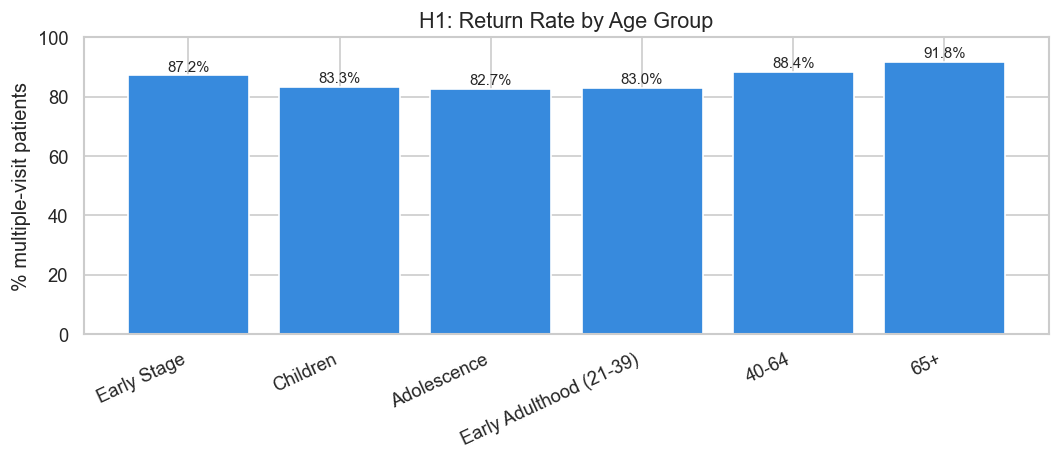

In [4]:
stat1, p1, dof1, tbl1 = run_chisq(conversion, 'age_group')
print_result('H1: Age group vs. return likelihood', stat1, p1, dof1)

return_by_age = (
    conversion.groupby('age_group')['visit_group']
    .apply(lambda s: (s=='Multiple Visits').mean()*100)
    .reset_index(name='pct_multi')
)

age_order = ['Early Stage','Children','Adolescence',
             'Early Adulthood (21-39)','40-64','65+']
return_by_age['age_group'] = pd.Categorical(
    return_by_age['age_group'], categories=age_order, ordered=True
)
return_by_age = return_by_age.sort_values('age_group')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(return_by_age['age_group'], return_by_age['pct_multi'], color=BLUE)
for _, row in return_by_age.iterrows():
    ax.text(row['age_group'], row['pct_multi']+0.5,
            f"{row['pct_multi']:.1f}%", ha='center', va='bottom', fontsize=9)
ax.set(xlabel=None, ylabel='% multiple-visit patients',
       title='H1: Return Rate by Age Group', ylim=(0,100))
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()


### H2 — Symptom (R) vs. routine (Z) diagnoses

In [5]:
rz = conversion[conversion['first_char'].isin(['R','Z'])]
stat2, p2, dof2, tbl2 = run_chisq(rz, 'first_char')
print_result('H2: Symptom (R) vs. routine (Z)', stat2, p2, dof2)

rz_rates = (
    rz.groupby('first_char')['visit_group']
    .apply(lambda s: (s=='Multiple Visits').mean()*100)
    .rename({'R':'Symptoms (R)','Z':'Routine/Preventive (Z)'})
)
print(rz_rates.to_string())


H2: Symptom (R) vs. routine (Z)
  Chi-sq = 5.25  |  df = 1  |  p = 2.20e-02  ->  [SIGNIFICANT]

first_char
Symptoms (R)              85.755458
Routine/Preventive (Z)    86.206037


### H3 — Admission type and return likelihood

H3: Admission type vs. return likelihood
  Chi-sq = 20781.65  |  df = 6  |  p = 0.00e+00  ->  [SIGNIFICANT]



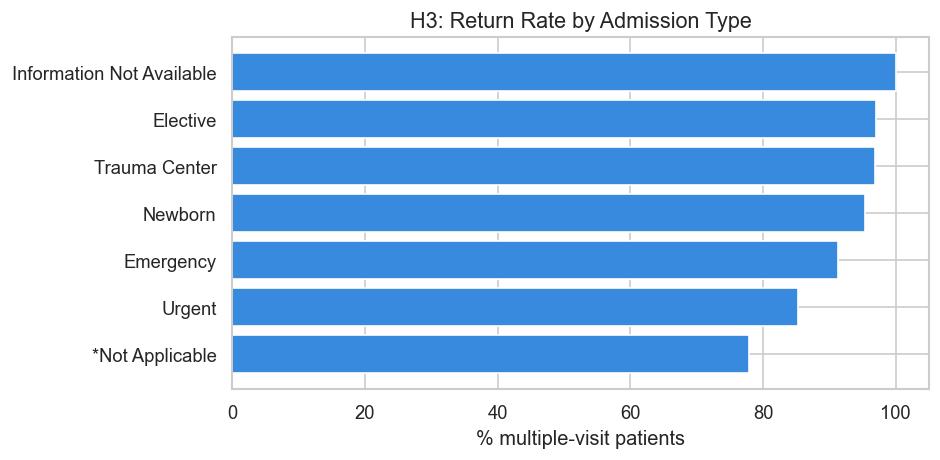

In [6]:
stat3, p3, dof3, tbl3 = run_chisq(conversion, 'AdmissionType')
print_result('H3: Admission type vs. return likelihood', stat3, p3, dof3)

admit_rates = (
    conversion.groupby('AdmissionType')['visit_group']
    .apply(lambda s: (s=='Multiple Visits').mean()*100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(admit_rates.index, admit_rates.values, color=BLUE)
ax.set(xlabel='% multiple-visit patients',
       title='H3: Return Rate by Admission Type')
plt.tight_layout(); plt.show()


---
## Secondary Hypotheses

### H4 — Age moderates symptom-driven return (21-39 vs. 65+)

In [7]:
r_sub = conversion[
    (conversion['first_char']=='R') &
    (conversion['age_group'].isin(['Early Adulthood (21-39)','65+']))
]
stat4, p4, dof4, tbl4 = run_chisq(r_sub, 'age_group')
print_result('H4: Age moderates symptom returns (R: 21-39 vs 65+)', stat4, p4, dof4)

rates4 = (
    r_sub.groupby('age_group')['visit_group']
    .apply(lambda s: (s=='Multiple Visits').mean()*100)
)
print(rates4.to_string())


H4: Age moderates symptom returns (R: 21-39 vs 65+)
  Chi-sq = 175.54  |  df = 1  |  p = 4.57e-40  ->  [SIGNIFICANT]

age_group
65+                        89.471123
Early Adulthood (21-39)    83.877609


### H5 — Routine care return rates differ by age

In [8]:
z_sub = conversion[
    (conversion['first_char']=='Z') &
    (conversion['age_group'].isin(['Children','Early Adulthood (21-39)','40-64','65+']))
]
stat5, p5, dof5, tbl5 = run_chisq(z_sub, 'age_group')
print_result('H5: Routine care (Z) return rates differ by age', stat5, p5, dof5)


H5: Routine care (Z) return rates differ by age
  Chi-sq = 1096.17  |  df = 3  |  p = 2.47e-237  ->  [SIGNIFICANT]



### H6 — Diagnosis type matters within young adults

In [9]:
young = conversion[
    (conversion['age_group']=='Early Adulthood (21-39)') &
    (conversion['first_char'].isin(['R','Z']))
]
stat6, p6, dof6, tbl6 = run_chisq(young, 'first_char')
print_result('H6: Diagnosis type matters within young adults (21-39)', stat6, p6, dof6)


H6: Diagnosis type matters within young adults (21-39)
  Chi-sq = 107.39  |  df = 1  |  p = 3.65e-25  ->  [SIGNIFICANT]



---
## Summary Table

In [10]:
results = [
    ('H1', 'Age group vs. return likelihood',          stat1, p1),
    ('H2', 'Symptom (R) vs. routine (Z) diagnoses',    stat2, p2),
    ('H3', 'Admission type vs. return likelihood',      stat3, p3),
    ('H4', 'Age moderates symptom returns (R)',         stat4, p4),
    ('H5', 'Routine care (Z) return rates by age',      stat5, p5),
    ('H6', 'Diagnosis type within young adults',        stat6, p6),
]

summary_df = pd.DataFrame(results, columns=['H','Description','Chi-sq','p-value'])
summary_df['Chi-sq'] = summary_df['Chi-sq'].round(2)
summary_df['p-value'] = summary_df['p-value'].map(lambda p: f'{p:.2e}')
summary_df['Significant'] = [p < 0.05 for _, _, _, p in results]
summary_df['Significant'] = summary_df['Significant'].map({True: 'Yes', False: 'No'})

display(summary_df.set_index('H'))


,Description,Chi-sq,p-value,Significant
H,,,,
H1,Age group vs. return likelihood,3642.04,0.00e+00,Yes
H2,Symptom (R) vs. routine (Z) diagnoses,5.25,2.20e-02,Yes
H3,Admission type vs. return likelihood,20781.65,0.00e+00,Yes
H4,Age moderates symptom returns (R),175.54,4.57e-40,Yes
H5,Routine care (Z) return rates by age,1096.17,2.47e-237,Yes
H6,Diagnosis type within young adults,107.39,3.65e-25,Yes
